# Pair Nulos

## **Ejercicios gestión de nulos**

El objetivo del ejercicio es identificar las columnas que contienen valores nulos y aplicar un proceso de imputación para manejarlos de manera adecuada.

Instrucciones:

1. **Identificación de Valores Nulos:** Identifica todas las columnas que contengan valores nulos en el DataFrame.
2. **Selección de Método de Imputación:** Discute en tu compañera cuál sería la mejor estrategia para manejar los valores nulos en cada una de las columnas identificadas en el paso anterior.
3. **Imputación de Valores Nulos:** Implementa el método de imputación seleccionado en el paso 2 para llenar los valores nulos en las columnas.
4. **Informe:** Añade al final de un jupyter una explicación breve que describa las columnas que tenían valores nulos, cómo decidiste imputarlos y cualquier observación adicional que consideres importante sobre el proceso de limpieza de datos.

**Nota:** Puedes utilizar cualquier método o estrategia de imputación que consideres adecuado para los datos y discutir las ventajas y desventajas de tu elección en el informe.


In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np


# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [13]:
df = pd.read_csv("pair.csv")
df.head()

,id,sueldo,estado_civil,num_hijos,ambito_laboral,genero,hipoteca
0,1,33795.0,soltero,0.0,tecnologia,mujer,si
1,2,18860.0,soltero,2.0,marketing,mujer,no
2,3,56158.0,casado,0.0,tecnologia,mujer,si
3,4,29284.0,soltero,0.0,educacion,mujer,si
4,5,24265.0,casado,0.0,NaN,mujer,no


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              200 non-null    int64  
 1   sueldo          170 non-null    float64
 2   estado_civil    194 non-null    object 
 3   num_hijos       198 non-null    float64
 4   ambito_laboral  140 non-null    object 
 5   genero          198 non-null    object 
 6   hipoteca        192 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 11.1+ KB


In [15]:
df['num_hijos'] = df['num_hijos'].astype("Int64")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              200 non-null    int64  
 1   sueldo          170 non-null    float64
 2   estado_civil    194 non-null    object 
 3   num_hijos       198 non-null    Int64  
 4   ambito_laboral  140 non-null    object 
 5   genero          198 non-null    object 
 6   hipoteca        192 non-null    object 
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 11.3+ KB


In [17]:
df.head()

,id,sueldo,estado_civil,num_hijos,ambito_laboral,genero,hipoteca
0,1,33795.0,soltero,0,tecnologia,mujer,si
1,2,18860.0,soltero,2,marketing,mujer,no
2,3,56158.0,casado,0,tecnologia,mujer,si
3,4,29284.0,soltero,0,educacion,mujer,si
4,5,24265.0,casado,0,NaN,mujer,no


In [19]:
df.isna().sum()/df.shape[0]*100

id                 0.0
sueldo            15.0
estado_civil       3.0
num_hijos          1.0
ambito_laboral    30.0
genero             1.0
hipoteca           4.0
dtype: float64

In [20]:
columnas_obj= df[df.columns[df.isnull().any()]].select_dtypes(include = "object").columns

In [21]:
columnas_obj

Index(['estado_civil', 'ambito_laboral', 'genero', 'hipoteca'], dtype='object')

In [22]:
df[columnas_obj].isna().sum()/df.shape[0]*100

estado_civil       3.0
ambito_laboral    30.0
genero             1.0
hipoteca           4.0
dtype: float64

In [24]:
for col in columnas_obj:
    print(f"La distribución de las categorías (incluyendo nulos) para la columna", col)
    display(df[col].value_counts(dropna=False, normalize=True) * 100)  # Convertimos a porcentaje
    print("........................")

La distribución de las categorías (incluyendo nulos) para la columna estado_civil


estado_civil
soltero       62.5
casado        23.0
divorciado    11.5
NaN            3.0
Name: proportion, dtype: float64

........................
La distribución de las categorías (incluyendo nulos) para la columna ambito_laboral


ambito_laboral
NaN           30.0
marketing     17.5
sanidad       15.0
educacion     15.0
tecnologia    13.5
finanzas       9.0
Name: proportion, dtype: float64

........................
La distribución de las categorías (incluyendo nulos) para la columna genero


genero
mujer     74.5
hombre    24.5
NaN        1.0
Name: proportion, dtype: float64

........................
La distribución de las categorías (incluyendo nulos) para la columna hipoteca


hipoteca
no     50.5
si     45.5
NaN     4.0
Name: proportion, dtype: float64

........................


In [25]:
col_moda = ["estado_civil", "genero"]
col_nueva_cat = ["ambito_laboral", "hipoteca"]

In [26]:
for col in col_moda:
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
for col in col_nueva_cat:
    df[col] = df[col].fillna('Desconocido')

In [29]:
df.isnull().sum()

id                 0
sueldo            30
estado_civil       0
num_hijos          2
ambito_laboral     0
genero             0
hipoteca           0
dtype: int64

In [46]:
df.sample(10)

,id,sueldo,estado_civil,num_hijos,ambito_laboral,genero,hipoteca
157,158,47320.0,soltero,1,educacion,mujer,no
177,178,55505.0,soltero,0,Desconocido,mujer,no
46,47,35159.0,soltero,0,marketing,hombre,si
57,58,31417.0,casado,2,sanidad,mujer,si
172,173,19636.0,soltero,1,Desconocido,hombre,no
178,179,NaN,soltero,0,Desconocido,mujer,no
102,103,NaN,soltero,0,Desconocido,mujer,si
65,66,51763.0,soltero,2,Desconocido,mujer,no
50,51,44531.0,soltero,0,Desconocido,mujer,si
53,54,41939.0,casado,0,sanidad,mujer,no


In [52]:
columnas_num= df[df.columns[df.isnull().any()]].select_dtypes(include = ["float","int"]).columns

In [53]:
columnas_num

Index(['sueldo', 'num_hijos'], dtype='object')

In [54]:
for col in columnas_num:
    print(f"La distribución de las categorías (incluyendo nulos) para la columna", col)
    display(df[col].value_counts(dropna=False, normalize=True) * 100)  # Convertimos a porcentaje
    print("........................")

La distribución de las categorías (incluyendo nulos) para la columna sueldo


sueldo
NaN        15.0
18860.0     0.5
33795.0     0.5
56158.0     0.5
29284.0     0.5
           ... 
58772.0     0.5
18197.0     0.5
52698.0     0.5
40671.0     0.5
43184.0     0.5
Name: proportion, Length: 171, dtype: float64

........................
La distribución de las categorías (incluyendo nulos) para la columna num_hijos


num_hijos
0       53.0
1       28.0
2       14.5
3        3.5
<NA>     1.0
Name: proportion, dtype: Float64

........................


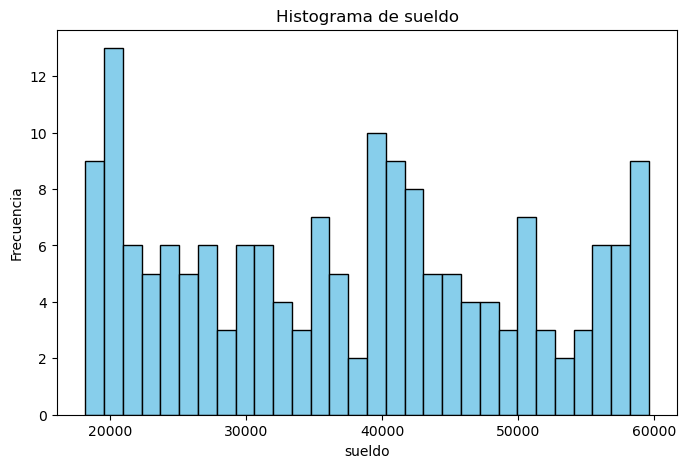

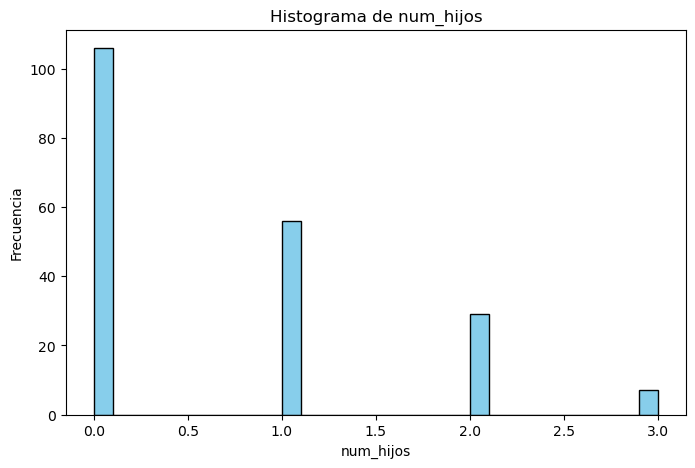

In [55]:
for col in list(columnas_num):
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

In [62]:
imputer_knn = KNNImputer(n_neighbors=5)
df['sueldo'] = imputer_knn.fit_transform(df[['sueldo']]).round(2)

In [63]:
df.sample(5)

,id,sueldo,estado_civil,num_hijos,ambito_laboral,genero,hipoteca
127,128,36141.0,soltero,0,Desconocido,mujer,si
148,149,41776.0,soltero,0,tecnologia,hombre,no
184,185,44309.0,divorciado,2,sanidad,hombre,si
79,80,39271.0,soltero,1,marketing,hombre,si
28,29,37476.0,soltero,3,tecnologia,hombre,no


In [64]:
df.isnull().sum()

id                0
sueldo            0
estado_civil      0
num_hijos         2
ambito_laboral    0
genero            0
hipoteca          0
dtype: int64

In [65]:
df["num_hijos"] = df["num_hijos"].fillna(df["num_hijos"].mode()[0])

In [66]:
df.isnull().sum()

id                0
sueldo            0
estado_civil      0
num_hijos         0
ambito_laboral    0
genero            0
hipoteca          0
dtype: int64

In [71]:
df.sample(5)

,id,sueldo,estado_civil,num_hijos,ambito_laboral,genero,hipoteca
118,119,51270.0,soltero,1,tecnologia,mujer,no
187,188,50970.0,divorciado,0,Desconocido,mujer,no
183,184,56559.0,soltero,1,Desconocido,mujer,si
79,80,39271.0,soltero,1,marketing,hombre,si
27,28,37118.0,soltero,0,Desconocido,mujer,si
